## importing needed libraries

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

### Creating Graphs


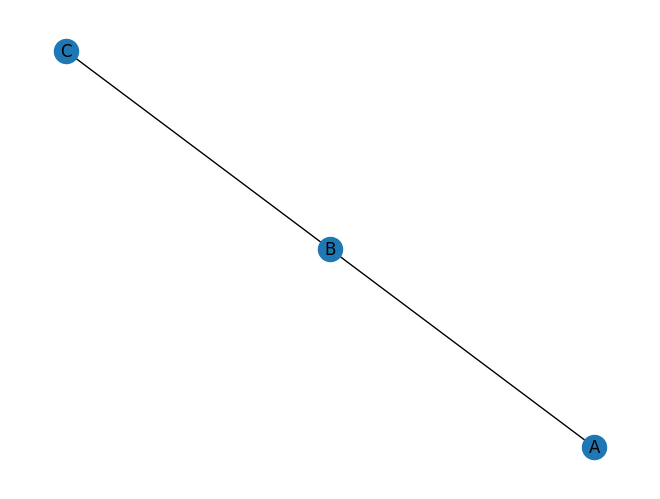

In [2]:
G = nx.Graph()
G.add_edge('A', 'B')
G.add_edge('C', 'B')


nx.draw(G, with_labels=True)
plt.show()


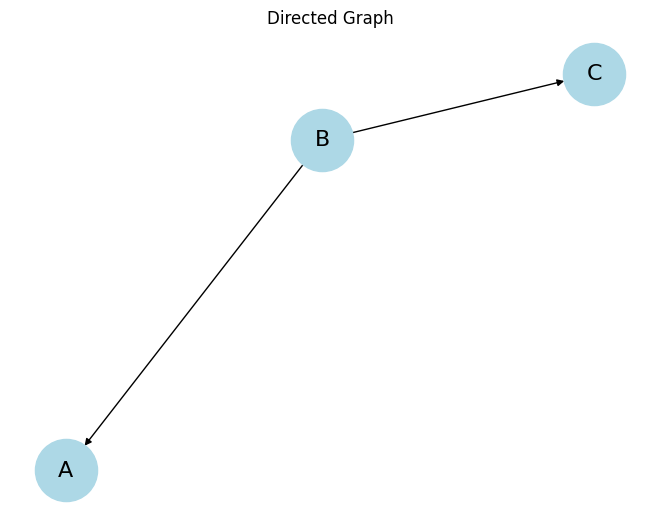

In [3]:

G = nx.DiGraph()
G.add_edge('B', 'A')
G.add_edge('B', 'C')

nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=16, arrows=True)
plt.title('Directed Graph')
plt.show()



### Weighted Networks


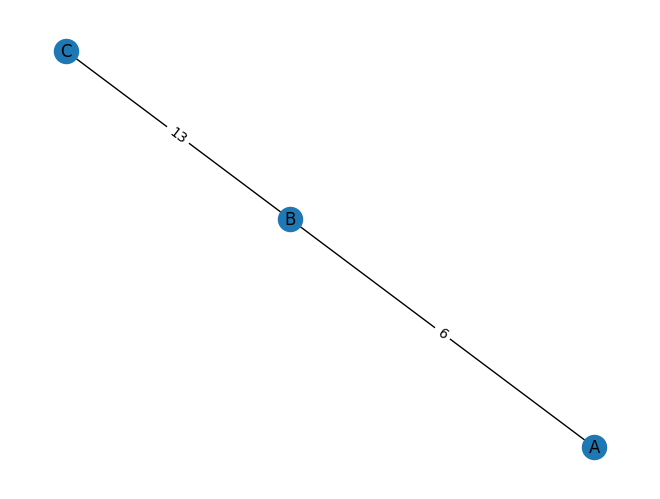

In [4]:
G = nx.Graph()
G.add_edge('A', 'B', weight=6)
G.add_edge('C', 'B', weight=13)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()


### Signed Networks

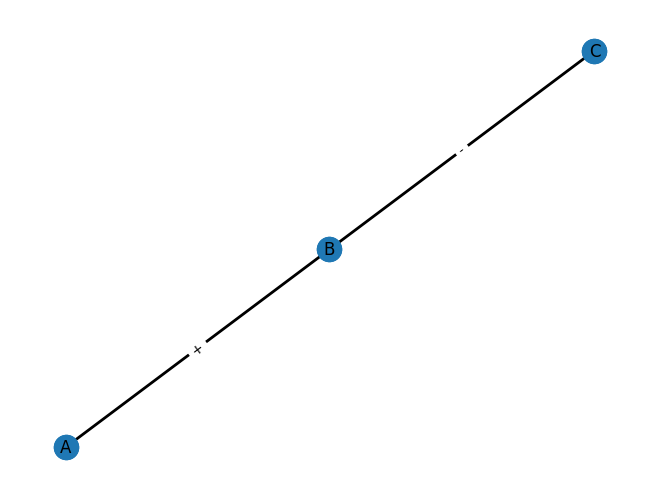

In [5]:
G = nx.Graph()
G.add_edge('A', 'B', sign="+")   
G.add_edge('C', 'B', sign="-")   


pos = nx.spring_layout(G)


nx.draw(G, pos, with_labels=True)


signs = nx.get_edge_attributes(G, 'sign')

edge_labels = {}
for edge, sign in signs.items():
    edge_labels[edge] = sign

nx.draw(G, pos, width=2)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()


### Graph Degree and Adjacency Matrix


Node degrees: {'A': 2, 'B': 2, 'C': 2, 'D': 2}


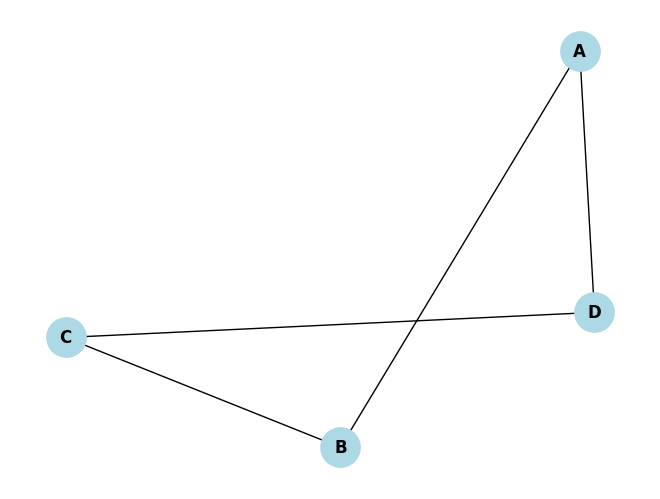

Adjacency matrix:
 [[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]


In [ ]:
G = nx.Graph()
G.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')])
degree = dict(G.degree())
print("Node degrees:", degree)
pos = nx.spring_layout(G) 
nx.draw(G, pos, with_labels=True, node_size=800, node_color="lightblue", font_size=12, font_weight="bold")

plt.show()
adj_matrix = nx.adjacency_matrix(G)
print("Adjacency matrix:\n", adj_matrix.todense())


# Clustering Coefficient

The clustering coefficient of a graph is a measure of how often the neighbors of a node are connected to each other. It is a way to assess how "cliquish" a node’s neighborhood is.

## 1. Local Clustering Coefficient

The local clustering coefficient $C_i$ for a node $i$ is the proportion of the actual connections between the neighbors of $i$ to the possible connections between them. It is defined as:

$$
C_i = \frac{2 \times \text{Number of triangles connected to node } i}{k_i (k_i - 1)}
$$

Where:
- $k_i$ is the degree of node $i$, i.e., the number of neighbors of node $i$.
- A triangle refers to three nodes where each is connected to the other two.

**Note:** The denominator, $k_i (k_i - 1) / 2$, represents the number of possible connections between the neighbors of $i$, while the numerator counts the actual number of such connections.

## 2. Global Clustering Coefficient

The global clustering coefficient (also called the transitivity) is a measure of the overall tendency of a graph to form clusters or cliques. It is defined as the ratio of the number of triangles to the number of connected triples of vertices (two edges with a common node).

$$
Transitivity= \frac{3 \times \text{Number of triangles}}{\text{Number of connected triples of vertices}}
$$

Where:
- A **triangle** is a set of three nodes that are mutually connected.
- A **connected triple** consists of three nodes where at least two edges are present.

## 3. Average Clustering Coefficient

The average clustering coefficient $\langle C \rangle$ is the average of the local clustering coefficients of all the nodes in the graph. It measures the typical level of clustering within the entire network. Mathematically, it is represented as:

$$
\langle C \rangle = \frac{1}{N} \sum_{i=1}^{N} C_i
$$

Where:
- $N$ is the total number of nodes in the graph.
- $C_i$ is the local clustering coefficient for node $i$.

### Key Insights:
- **High clustering**: Nodes tend to form tightly connected groups. These clusters can often represent communities.
- **Low clustering**: Nodes are sparsely connected, and the network does not exhibit a strong community structure.

### Applications:
- **Social Networks**: Clustering can indicate the presence of closely-knit groups or communities (e.g., friend groups).
- **Biological Networks**: High clustering often occurs in protein-protein interaction networks, where functional modules are observed.
- **Technological Networks**: In networks like the internet or power grids, clustering can suggest areas with more redundancy or robustness.


Clustering Coefficients for each node:
Node A: 0.6666666666666666
Node B: 0.6666666666666666
Node C: 0.3333333333333333
Node D: 0
Node E: 0.16666666666666666
Node F: 0.3333333333333333
Node G: 0
Node H: 0
Node I: 0
Node J: 0
Node K: 1.0

Average Clustering Coefficient: 0.28787878787878785


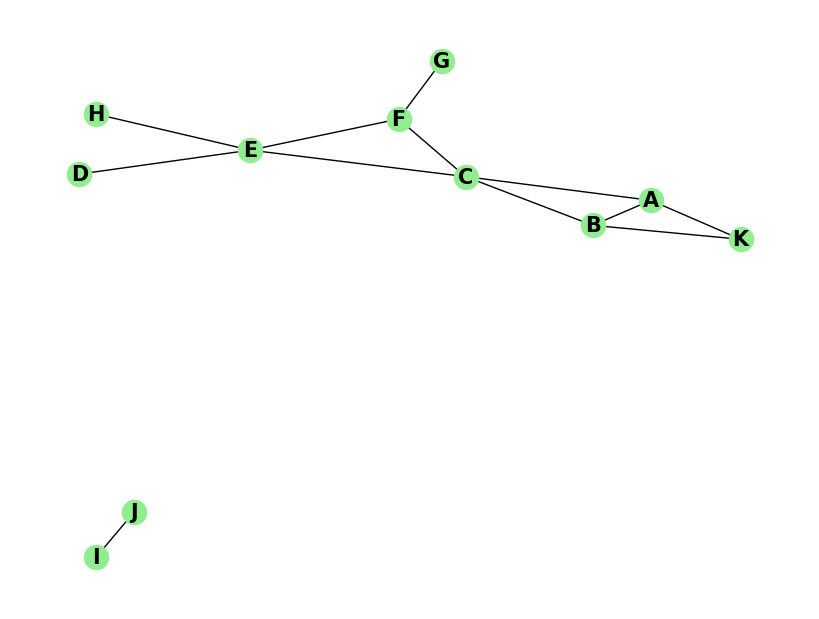

In [7]:
G = nx.Graph()

nodes = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"]
edges = [("A", "B"), ("A", "C"), ("A", "K"), ("B", "C"), 
         ("B", "K"), ("C", "E"), ("C", "F"), ("D", "E"), 
         ("E", "F"), ("F", "G"), ("E", "H"), ("I","J")]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

clustering_coefficients = nx.clustering(G)
print("Clustering Coefficients for each node:")
for node, coeff in clustering_coefficients.items():
    print(f"Node {node}: {coeff}")

average_clustering = nx.average_clustering(G)
print("\nAverage Clustering Coefficient:", average_clustering)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G) 
nx.draw(G, pos, with_labels=True, node_color="lightgreen", font_size=15, font_weight="bold", edge_color="black")
plt.show()


## Transitivity vs. Average Clustering Coefficient


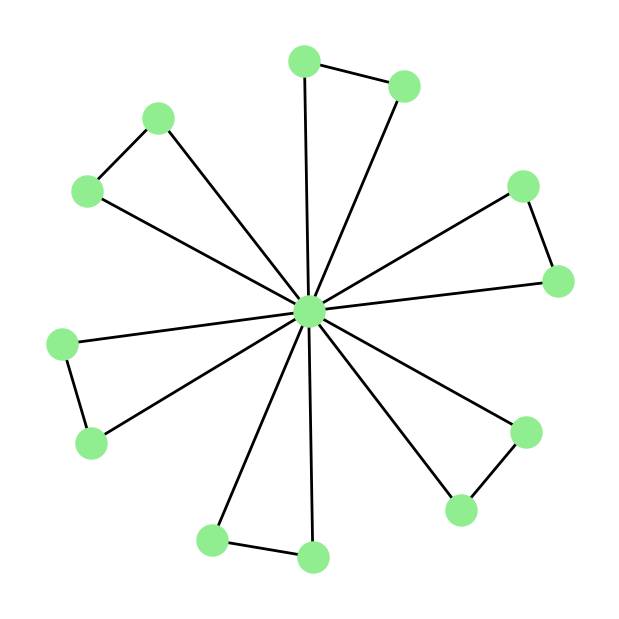

Transitivity of the graph: 0.23076923076923078
Average Clustering Coefficient of the graph: 0.9300699300699301


In [8]:
G_star_modified = nx.Graph()
G_star_modified.add_node(0)  
for i in range(1, 13):
    G_star_modified.add_edge(0, i)

G_star_modified.add_edge(1, 2)
G_star_modified.add_edge(3, 4)
G_star_modified.add_edge(5, 6)
G_star_modified.add_edge(7, 8)
G_star_modified.add_edge(9, 10)
G_star_modified.add_edge(11, 12)

pos = nx.spring_layout(G_star_modified, seed=42)  
plt.figure(figsize=(6, 6))
nx.draw(G_star_modified, pos, with_labels=False, node_color='lightgreen', node_size=500, edge_color='black', width=2)
plt.show()

transitivity = nx.transitivity(G_star_modified)
print("Transitivity of the graph:", transitivity)

avg_clustering_coeff = nx.average_clustering(G_star_modified)
print("Average Clustering Coefficient of the graph:", avg_clustering_coeff)



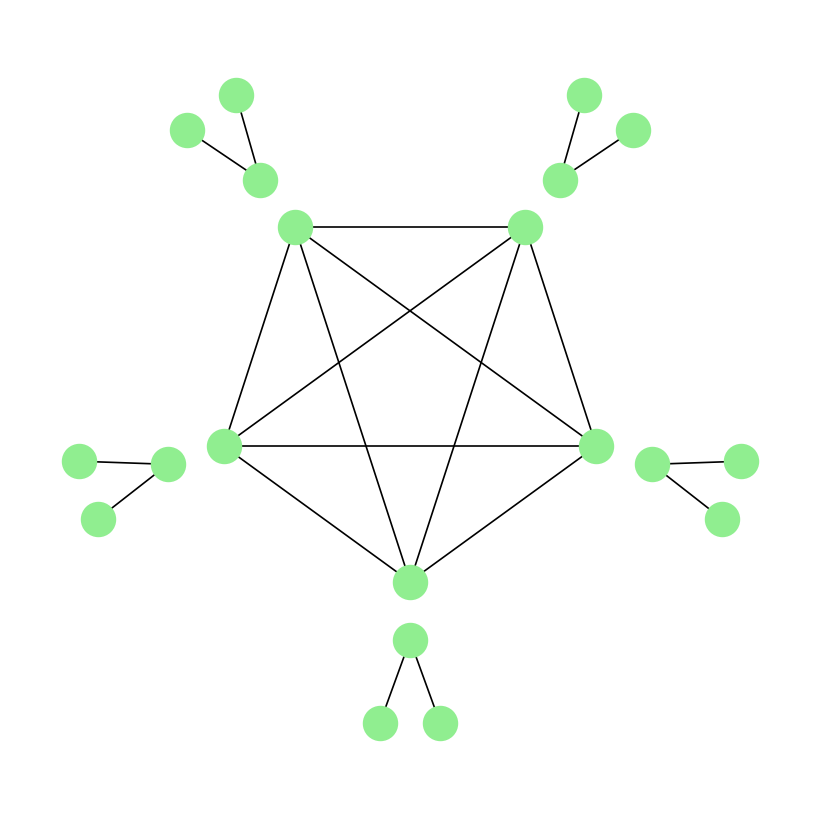

Transitivity: 0.8571428571428571
Average Clustering Coefficient: 0.25


In [9]:
G = nx.Graph()

central_nodes = range(5)
G.add_nodes_from(central_nodes)

for i in central_nodes:
    for j in central_nodes:
        if i < j:
            G.add_edge(i, j)

peripheral_offset = 5
for i in range(5):
    peripheral_1 = peripheral_offset + 3 * i
    peripheral_2 = peripheral_offset + 3 * i + 1
    peripheral_3 = peripheral_offset + 3 * i + 2

    G.add_edge(peripheral_1, peripheral_2)
    G.add_edge(peripheral_3, peripheral_2)

angle_step = 2 * np.pi / 5
pentagon_radius = 1.0
arrow_offset_radius = 0.5
arrow_distance = 1.2  
pos = {}

for i in range(5):
    angle = i * angle_step - np.pi / 2
    center_x = pentagon_radius * np.cos(angle)
    center_y = pentagon_radius * np.sin(angle)

    pos[i] = (center_x, center_y)

    arrow_center_x = center_x + arrow_distance * np.cos(angle)
    arrow_center_y = center_y + arrow_distance * np.sin(angle)

    middle_node = peripheral_offset + 3 * i + 1  
    left_node = peripheral_offset + 3 * i
    right_node = peripheral_offset + 3 * i + 2

    pointer_distance = 1.3 
    pos[middle_node] = (pointer_distance * np.cos(angle), pointer_distance * np.sin(angle))

    angle_offset = np.pi / 10
    pos[left_node] = (arrow_center_x - arrow_offset_radius * np.cos(angle + angle_offset),
                      arrow_center_y - arrow_offset_radius * np.sin(angle + angle_offset))
    pos[right_node] = (arrow_center_x - arrow_offset_radius * np.cos(angle - angle_offset),
                       arrow_center_y - arrow_offset_radius * np.sin(angle - angle_offset))

plt.figure(figsize=(8, 8))
nx.draw(G, pos, with_labels=False, node_color='lightgreen', node_size=600, edge_color='black', width=1.2)

plt.axis('equal')  
plt.axis('off')
#plt.tight_layout()
plt.show()

transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)

print(f"Transitivity: {transitivity}")
print(f"Average Clustering Coefficient: {avg_clustering}")

### Connected Graph 

A connected graph is a graph in which there is a path between every pair of vertices. In the example below, you can see that every node is reachable from any other node, meaning the graph is fully connected.



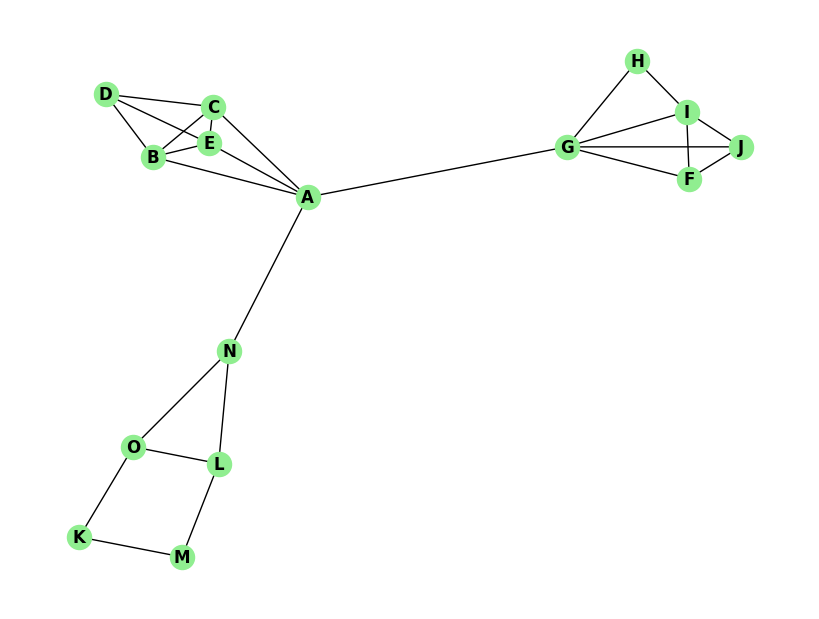

In [10]:

G = nx.Graph()

edges = [
    ('A', 'B'), ('A', 'C'), ('A', 'E'), ('A', 'G'), ('A', 'N'),  \
    ('B', 'C'), ('B', 'E'),('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'),
    ('G', 'F'), ('G', 'H'), ('G', 'I'), ('G', 'J'), 
    ('F', 'J'),('F', 'I'),  ('I', 'J'),('I', 'H'),
    ('N', 'L'), ('N', 'O'), 
    ('M', 'L'), ('M', 'K'), ('O', 'K'),('O', 'L')
]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G,seed=50)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', font_weight='bold',  font_size=12, edge_color='black')
plt.show()


In [11]:
nx.is_connected(G)

True

### Graph component
The number of components tells us how many separate subgraphs exist in the graph.

let's see how we can find the components in this graph.




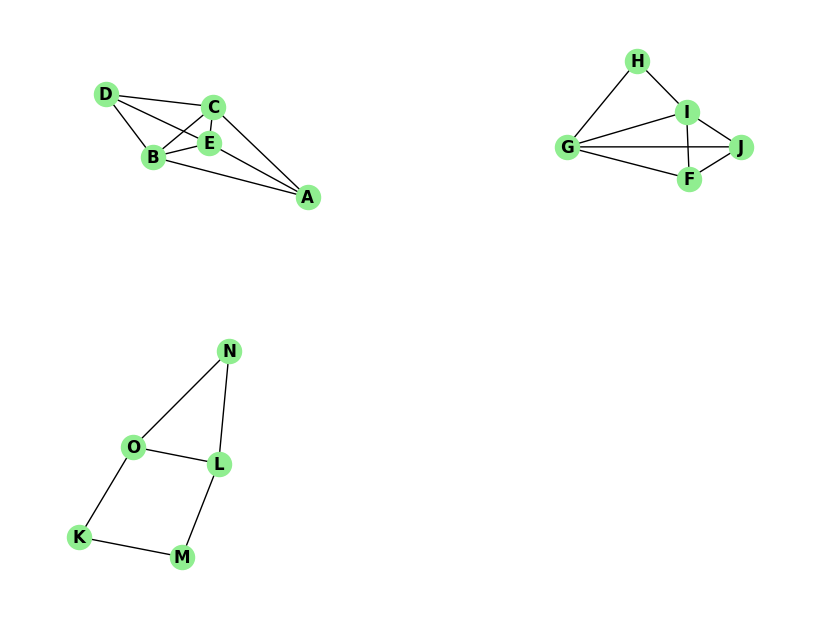

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
    ('A', 'B'), ('A', 'C'), ('A', 'E'), # Removed ('A', 'G') and ('A', 'N')
    ('B', 'C'), ('B', 'E'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'),
    ('G', 'F'), ('G', 'H'), ('G', 'I'), ('G', 'J'),
    ('F', 'J'), ('F', 'I'), ('I', 'J'), ('I', 'H'),
    ('N', 'L'), ('N', 'O'),
    ('M', 'L'), ('M', 'K'), ('O', 'K'), ('O', 'L')
]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
full_G = nx.Graph()
full_edges = [
    ('A', 'B'), ('A', 'C'), ('A', 'E'), ('A', 'G'), ('A', 'N'),
    ('B', 'C'), ('B', 'E'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'),
    ('G', 'F'), ('G', 'H'), ('G', 'I'), ('G', 'J'),
    ('F', 'J'), ('F', 'I'), ('I', 'J'), ('I', 'H'),
    ('N', 'L'), ('N', 'O'),
    ('M', 'L'), ('M', 'K'), ('O', 'K'), ('O', 'L')
]
full_G.add_edges_from(full_edges)

pos = nx.spring_layout(full_G, seed=50)

nx.draw(G, pos, with_labels=True, node_color='lightgreen', font_weight='bold', font_size=12, edge_color='black')
plt.savefig('component_modified.png')
plt.show()

In [13]:
nx.number_connected_components(G)


3

In [14]:
sorted(nx.connected_components(G))


[{'A', 'B', 'C', 'D', 'E'},
 {'F', 'G', 'H', 'I', 'J'},
 {'K', 'L', 'M', 'N', 'O'}]

In [15]:
nx.node_connected_component(G,'M')

{'K', 'L', 'M', 'N', 'O'}

### 1. Path Length

![Graph showing distances between nodes](AH.png)


Path length refers to the number of steps (or hops) it takes to travel from one node to another. In this graph, there are two possible paths from node **A** to node **H**:

1. **Path 1**: A → B → C → E → H (4 "hops")
2. **Path 2**: A → B → C → F → E → H (5 "hops")


Path length is a fundamental concept in network analysis, representing the distance between any two points.

![Graph showing distances between nodes](A_H.png)


### 2. Average Path Length
- **Definition**: The average path length is the average of the shortest path distances between all pairs of nodes in the graph.
- **Formula**: 
  $$
  \text{Average Path Length} = \frac{1}{N(N-1)} \sum_{u \neq v} d(u, v)
  $$
  where  **N**  is the number of nodes, and  **d(u, v)**  is the shortest path distance between nodes  **u**  and  **v** .



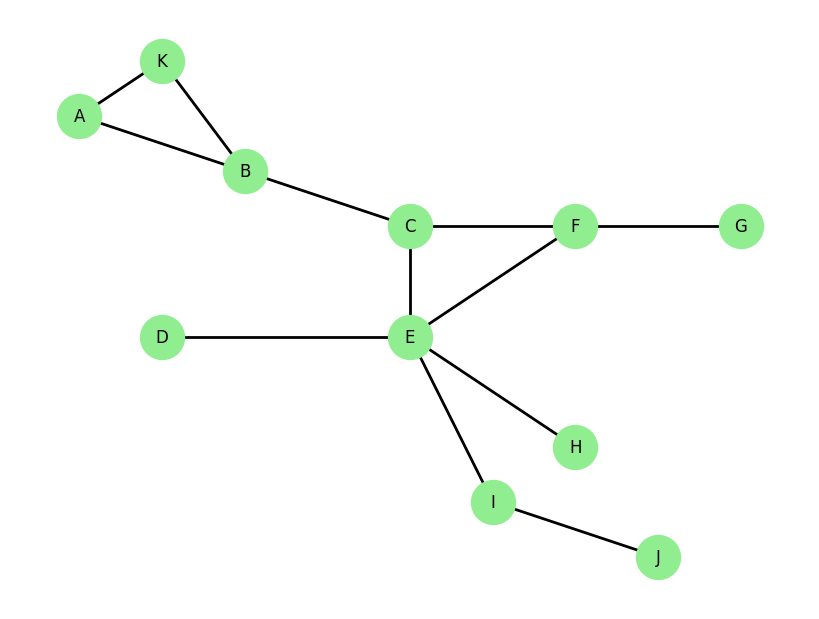

In [16]:

G = nx.Graph()

nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
G.add_nodes_from(nodes)

edges = [
    ('A', 'B'), ('A', 'K'), ('B', 'C'), ('B', 'K'), ('C', 'E'),
    ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'H'), ('I', 'E'),
    ('I', 'J'), ('F', 'G')
]
G.add_edges_from(edges)

pos = {
    'A': (0, 2), 'B': (1, 1.5), 'C': (2, 1), 'D': (0.5, 0),
    'E': (2, 0), 'F': (3, 1), 'G': (4, 1), 'H': (3, -1),
    'I': (2.5, -1.5), 'J': (3.5, -2), 'K': (0.5, 2.5)
}

plt.figure(figsize=(8, 6))

nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1000, font_size=12, edge_color='black', width=2)

plt.show()

In [17]:
shortest_path_A_H = nx.shortest_path(G, 'A', 'H')
shortest_path_length_A_H = nx.shortest_path_length(G, 'A', 'H')

avg_shortest_path_length = nx.average_shortest_path_length(G)

print("Shortest path between A and H:", shortest_path_A_H)
print("Shortest path length between A and H:", shortest_path_length_A_H)
print("Average shortest path length:", avg_shortest_path_length)


Shortest path between A and H: ['A', 'B', 'C', 'E', 'H']
Shortest path length between A and H: 4
Average shortest path length: 2.5272727272727273



### 3. Diameter

The diameter is the maximum distance between any pair of nodes in the graph. Here, the longest path between any two nodes is between nodes **k** and **J** or nodes **A** and **J** , passing through several intermediate nodes. 


![Graph showing distances between nodes](dia.png)

In [18]:
nx.diameter(G)

5

degree and clustering distribution

Number of nodes: 34
Number of edges: 78


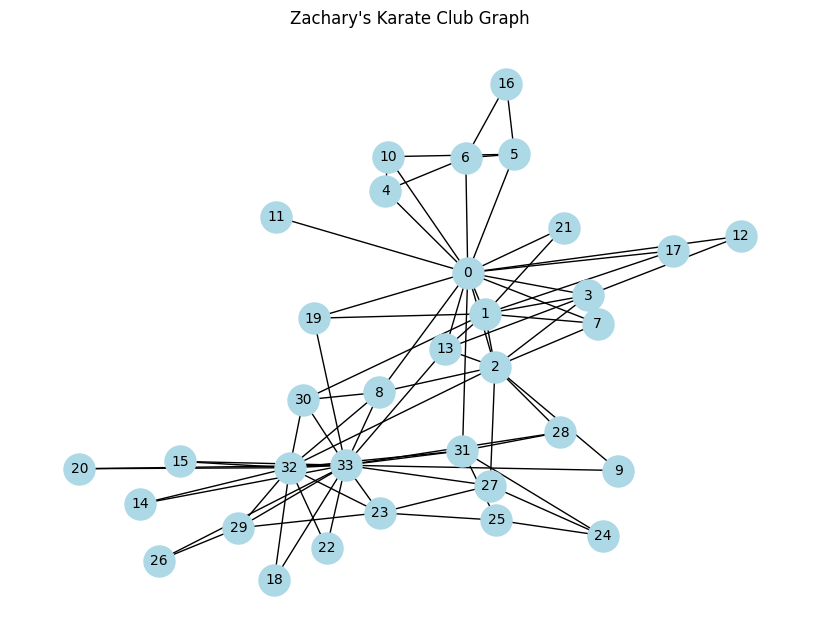

In [43]:
G = nx.karate_club_graph()
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
plt.title("Zachary's Karate Club Graph")
plt.show()


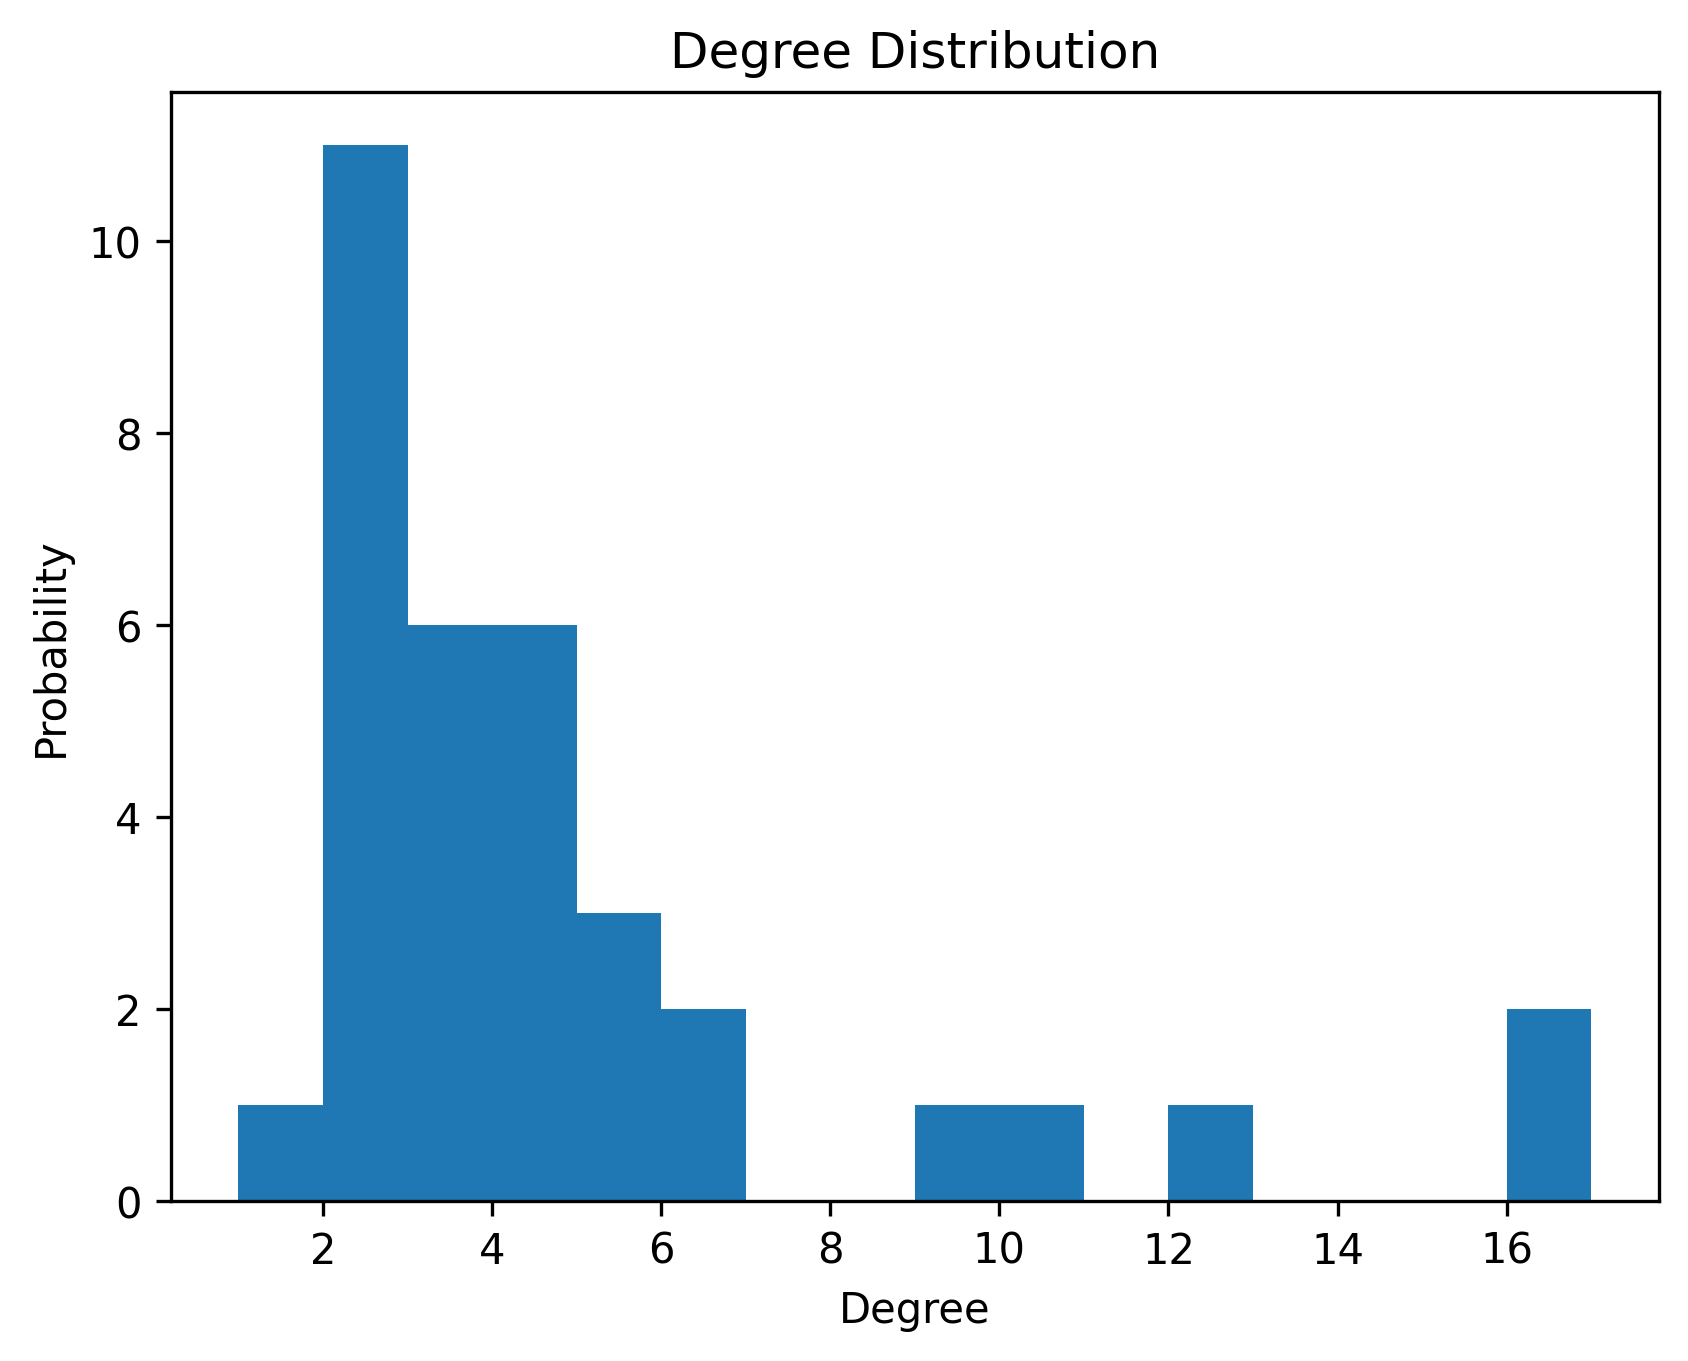

In [20]:
G = nx.karate_club_graph()

degrees = [G.degree(i) for i in G.nodes()]

plt.figure(dpi=300)

plt.hist(degrees, bins=range(min(degrees), max(degrees) + 1))
plt.xlabel('Degree')
plt.ylabel('Probability')
plt.title('Degree Distribution')
plt.show()


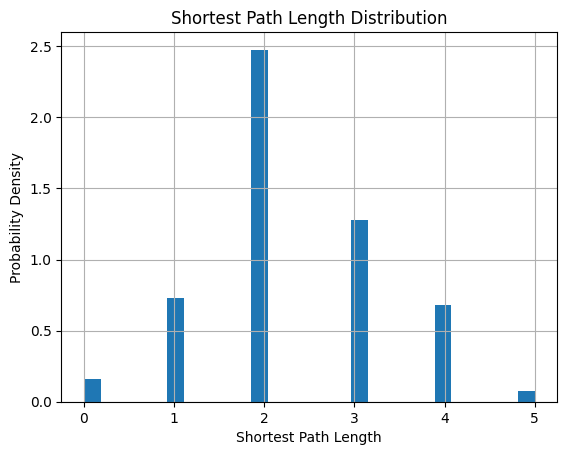

In [21]:

path_lengths = dict(nx.shortest_path_length(G))
path_lengths_list = [j for i in path_lengths.values() for j in i.values()]#

plt.hist(path_lengths_list, bins='auto', density=True)
plt.xlabel('Shortest Path Length')
plt.ylabel('Probability Density')
plt.title('Shortest Path Length Distribution')
plt.grid(True)
plt.show()

### NetworkX Networks


<h3>
    <span style="color:#00FF00">G</span>
    <span style="color:#FF7F00">o</span>
    <span style="color:#FFFF00">o</span>
    <span style="color:#FF0000">g</span>
    <span style="color:#0000FF">l</span>
    <span style="color:#8B00FF">e</span> it: NetworkX Graph Generators
</h3>

[https://networkx.org/documentation/stable/reference/generators.html](https://networkx.org/documentation/stable/reference/generators.html)


### Network Examples


## 1. **Random Network (Erdős-Rényi Model)**
The Erdős-Rényi random graph is generated by connecting nodes randomly. Each pair of nodes is connected with a probability `p`.

**Parameters:**
- `n`: Number of nodes.
- `p`: Probability for edge creation.

**Use Case:**
- Useful for modeling random processes such as rumor spreading or social network formation where there’s no bias in connecting nodes.




2.263838383838384
0.08905900961783315


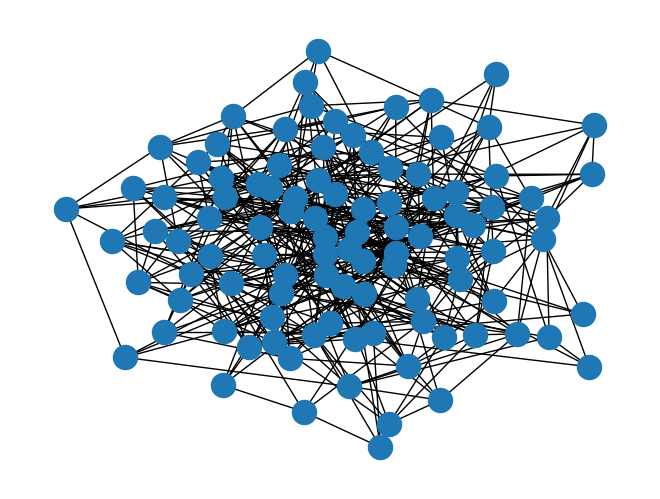

In [28]:
Er= nx.erdos_renyi_graph(100,0.1)
C=nx.average_clustering(Er)
L=nx.average_shortest_path_length(Er)
print(L)
print(C)
nx.draw(Er)

## 2. **Small-World Network (Watts-Strogatz Model)**
This network starts as a ring lattice and rewires some edges randomly. It retains the local clustering of lattice graphs and has the short average path lengths of random graphs.

**Parameters:**
- `n`: Number of nodes.
- `k`: Each node is joined with its `k` nearest neighbors in a ring topology.
- `p`: Probability of rewiring each edge.

**Use Case:**
- Used to model social networks and neural networks, where there’s high clustering and short path lengths between any two nodes.


25.252525252525253
0.0


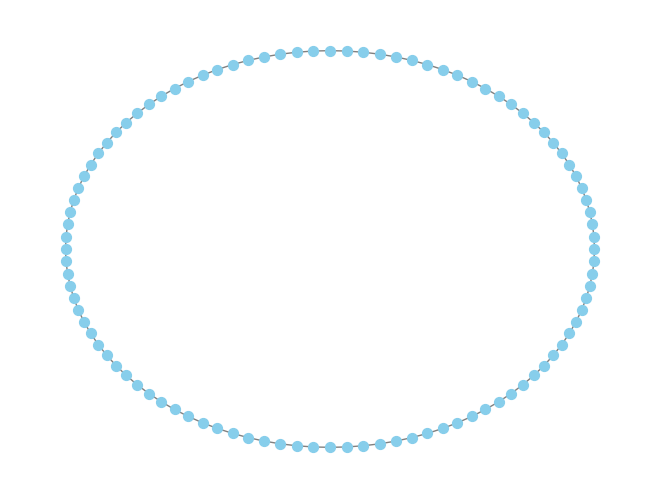

In [33]:
W= nx.watts_strogatz_graph(100,2,0)
C=nx.average_clustering(W)
L=nx.average_shortest_path_length(W)
print(L)
print(C)
pos=nx.circular_layout(W)
nx.draw(
    W, pos,
    node_size=50,
    node_color="skyblue",
    edge_color="gray",
    with_labels=False
)


## 3. **Barabási-Albert Network (Scale-Free Network)**
This is a scale-free network where nodes are added one at a time, and each new node is connected to existing nodes with a probability that is proportional to the number of links that the existing nodes already have.

**Parameters:**
- `n`: Number of nodes.
- `m`: Number of edges to attach from a new node to existing nodes.

**Use Case:**
- Used to model networks like the Internet or citation networks, where some nodes (hubs) have a much higher degree than others.


2.263838383838384
0.08905900961783315


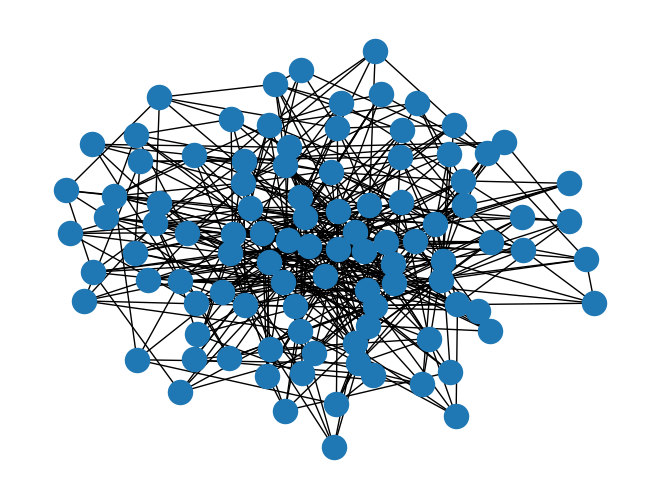

In [34]:
Ba= nx.barabasi_albert_graph(100,5)
C=nx.average_clustering(Er)
L=nx.average_shortest_path_length(Er)
print(L)
print(C)
nx.draw(Ba)

## 4. **Random Regular Network**
A random regular graph is a graph where each node has the same number of neighbors (`degree`), and the neighbors are chosen randomly.

**Parameters:**
- `n`: Number of nodes.
- `d`: Degree of each node (the number of neighbors).

**Use Case:**
- Useful for modeling systems with uniform interaction degrees, such as some physical and biological systems.


25.252525252525253
0.0


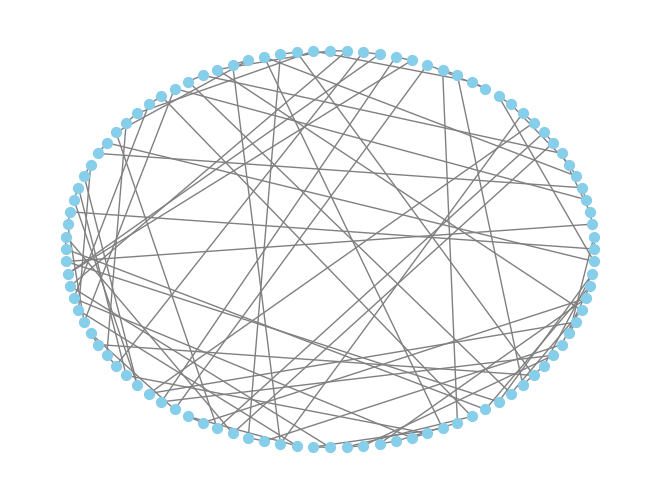

In [36]:
Rr= nx.random_regular_graph(2,100)
C=nx.average_clustering(Rr)
L=nx.average_shortest_path_length(Rr)
print(L)
print(C)
pos=nx.circular_layout(Rr)
nx.draw(
    Rr, pos,
    node_size=50,
    node_color="skyblue",
    edge_color="gray",
    with_labels=False
)